# Background

A large e-commerce organization operates a homepage recommendation slot that displays one product to each visiting user. The company aims to maximize long-term net profit from these recommendations.

You are provided with a dataset of **498 user sessions**, each representing how a particular user would respond to each of six products.

Link for accessing dataset:
https://drive.google.com/file/d/14yDuW-zFs9-fh6ySH9xmULFcZuKVhn1r/view?usp=sharing


The dataset structure is:

*UserID, Product1, cost1, Product2, cost2, … , Product6, cost6*


Each row corresponds to one user and contains the following information.

## Product X column
The value under **Product X** represents the actual revenue the system would earn from that specific user if Product X were shown.

Revenue varies across users because:

- different users purchase different quantities  
- some users click while others ignore  
- some users spend more  
- some users purchase premium items or bundles  

Thus, actual revenue is **user-dependent**, not product-dependent.  
The same product may generate high revenue from one user and very low revenue from another.

## Cost X column
The value under **cost X** represents the personalized promotional cost incurred to show Product X to that user. This may include:

- dynamic advertisement bidding cost (CPC)  
- discounts or coupon values offered  
- targeted promotion cost  
- personalization overhead  

Costs differ across users because:

- some users require higher incentive levels  
- some are expensive to target via ads  
- some convert easily with minimal cost  

Thus, cost is also **user-dependent** and varies per session.



# Environment Dynamics

## Arms
In the Multi-Armed Bandit formulation:

There are **6 arms**:
A = {1, 2, 3, 4, 5, 6}

Arm X corresponds to recommending **Product X**.

## Reward
For each product X and each user session i:

$
\text{NetReward}_{i,X} = \text{Product}_{i,X} - \text{Cost}_{i,X}
$

This net reward represents the **profit** gained from showing product X to user i.  
This is the metric the organization aims to maximize.


# Current Organizational Policy

The organization currently follows a **random recommendation policy**:

“For each user visit, randomly select one of the six products and display it.”

This strategy:

- does not learn from previous outcomes  
- does not identify which products consistently deliver higher profit  
- wastes impressions on low-value products  
- provides unstable and suboptimal profit performance  

Management asks you to investigate:

- Whether a learning-based approach can yield better decisions  
- Which products are actually profitable when user variability is considered  
- How alternative strategies compare to the random policy  



# Requirements and Deliverables:
Implement the Multi-Arm Bandit Problem for the given above scenario.

### Initialize constants

In [ ]:

# Initialize Constants
import pandas as pd
import numpy as np

# Design a Product Environment with Reward calculation (1M)

In [ ]:
# Code for Dataset loading and print dataset statistics along with reward function
df = pd.read_csv("Dataset_Product_Recommendation.csv")


In [ ]:
# Identify one product that frequently gives high positive profit.
# Identify one product that frequently gives low or negative profit across the user sessions.
#-----write your code below this line---------

class ProductEnvironment:

    def __init__(self, df):
        self.df = df
        self.num_products = 6

        # Compute net reward for each product
        for i in range(1, self.num_products + 1):
            self.df[f"net_reward_{i}"] = self.df[f"Product {i}"] - self.df[f"cost {i}"]

    def product_profit_summary(self):
        """
        Computes:
        - Mean profit per product
        - % of users for which profit was positive
        """
        results = {}

        for i in range(1, self.num_products + 1):
            net_col = f"net_reward_{i}"
            mean_profit = self.df[net_col].mean()
            positive_ratio = (self.df[net_col] > 0).mean()  # fraction of sessions with positive profit

            results[i] = {
                "mean_profit": mean_profit,
                "positive_profit_ratio": positive_ratio
            }
        return results

    def identify_best_and_worst_products(self):
        """
        Identifies:
        - Product with highest proportion of positive-profit sessions
        - Product with lowest (or negative) proportion of positive-profit sessions
        """
        summary = self.product_profit_summary()

        # product with highest positive profit frequency
        best_product = max(summary, key=lambda x: summary[x]["mean_profit"])

        # product with lowest positive profit frequency
        worst_product = min(summary, key=lambda x: summary[x]["mean_profit"])

        return best_product, worst_product

env = ProductEnvironment(df)

summary_stats = env.product_profit_summary()
best_product, worst_product = env.identify_best_and_worst_products()

print("Product Profit Summary:")
for p, stats in summary_stats.items():
    print(f"Product {p}: Mean Profit = {stats['mean_profit']:.2f}, "
          f"Positive Profit Frequency = {stats['positive_profit_ratio']*100:.2f}%")

print(f"\nProduct that frequently gives HIGH positive profit: Product {best_product}")
print(f"Product that frequently gives LOW or NEGATIVE profit: Product {worst_product}")


Product Profit Summary:
Product 1: Mean Profit = 7.06, Positive Profit Frequency = 100.00%
Product 2: Mean Profit = 66.99, Positive Profit Frequency = 100.00%
Product 3: Mean Profit = 31.42, Positive Profit Frequency = 100.00%
Product 4: Mean Profit = 9.60, Positive Profit Frequency = 100.00%
Product 5: Mean Profit = -17.06, Positive Profit Frequency = 0.00%
Product 6: Mean Profit = 36.99, Positive Profit Frequency = 100.00%

Product that frequently gives HIGH positive profit: Product 2
Product that frequently gives LOW or NEGATIVE profit: Product 5


## **Interpretation**

Although multiple products have a 100% positive profit rate, Product 2 consistently generates significantly higher profit magnitude and is therefore the most profitable arm.

#Implement the existing Strategy 1 (1M)



In [ ]:
# Which product appears good and which appears poor under the existing process?
# What is the approximate average profit per round under this strategy?
# Did randomness occasionally pick a good product?

#-----write your code below this line---------

# Compute Net Rewards
# NetReward = ProductX – CostX

net_rewards = pd.DataFrame()
df.columns = df.columns.str.replace(" ", "").str.lower()

for i in range(1, 7):  # products 1 to 6
    net_rewards[f"net_{i}"] = df[f"product{i}"] - df[f"cost{i}"]

# Implement RANDOM Strategy
np.random.seed(0)  # reproducibility

# Randomly choose one product (arm) for each user
choices = np.random.randint(1, 7, size=len(df))

# Collect profit for each random choice
profits = []
for idx, arm in enumerate(choices):
    profits.append(net_rewards.iloc[idx, arm - 1])

profits = np.array(profits)

# Compute Metrics
avg_profit_random = profits.mean()
avg_per_product = net_rewards.mean()

# Evaluation
print("\n==============================")
print("1. Which products appear good or poor?")
print("==============================")
print(avg_per_product)

# Identify best and worst
best_product = avg_per_product.idxmax()
worst_product = avg_per_product.idxmin()

print(f"\nBest performing product: {best_product}")
print(f"Worst performing product: {worst_product}")

print("\n==============================")
print("2. Approximate average profit per round (Random Strategy)")
print("==============================")
print(f"Average Profit Per Round: {avg_profit_random:.4f}")

print("\n==============================")
print("3. Did randomness occasionally pick a good product?")
print("==============================")

# Count how many times random chose the best product
best_arm_number = int(best_product.split("_")[1])
best_count = np.sum(choices == best_arm_number)

print(f"Random strategy picked the best product ({best_product}) {best_count} times out of {len(df)} rounds.")
print(f"Example first 20 random picks: {choices[:20]}")


1. Which products appear good or poor?
net_1     7.062784
net_2    66.992995
net_3    31.418452
net_4     9.596789
net_5   -17.064884
net_6    36.986031
dtype: float64

Best performing product: net_2
Worst performing product: net_5

2. Approximate average profit per round (Random Strategy)
Average Profit Per Round: 21.5813

3. Did randomness occasionally pick a good product?
Random strategy picked the best product (net_2) 80 times out of 498 rounds.
Example first 20 random picks: [5 6 1 4 4 4 2 4 6 3 5 1 1 5 3 2 1 2 6 2]


## **Interpretation (Random Strategy):**

Under the existing random recommendation process, **Product 2 appears clearly good** as it delivers the highest average profit, while **Product 5 is poor**, consistently generating negative profit. The random strategy earns a modest average profit per round (~21.6) only because it **occasionally selects the best product**, but it wastes many impressions on suboptimal and loss-making products, leading to inefficient performance overall.


---



# Strategy 2 (0.5 M)
Instead of picking randomly, try each product a few times, measure the average profit, and then always select the best-performing one.

In [ ]:
#  Determine the cumulative net profit achieved. Which product tends to be repeatedly chosen?

#-----write your code below this line---------
net_rewards = pd.DataFrame()
df.columns = df.columns.str.replace(" ", "").str.lower()
for i in range(1, 7):
    net_rewards[f"net_{i}"] = df[f"product{i}"] - df[f"cost{i}"]

# Explore-Then-Commit Strategy
num_products = 6
explore_rounds = 10  # Number of times to test each product
total_rounds = len(df)

choices = []
profits_2 = []

# Exploration phase
for product in range(1, num_products + 1):
    for i in range(explore_rounds):
        idx = (product - 1) * explore_rounds + i
        if idx >= total_rounds:
            break  # safety if dataset is smaller than needed

        net = net_rewards.iloc[idx, product - 1]
        choices.append(product)
        profits_2.append(net)

# Compute average profit per product during exploration
avg_per_product = []

for product in range(1, num_products + 1):
    indices = [i for i, c in enumerate(choices) if c == product]
    product_avg = np.mean([profits_2[i] for i in indices])
    avg_per_product.append(product_avg)

# Identify best product based on exploration
best_product = np.argmax(avg_per_product) + 1

# Commit phase
for idx in range(num_products * explore_rounds, total_rounds):
    net = net_rewards.iloc[idx, best_product - 1]
    choices.append(best_product)
    profits_2.append(net)

# Reporting
cumulative_profit = np.sum(profits_2)
chosen_counts = pd.Series(choices).value_counts()

print("===================================")
print("Average Profit Per Product (Exploration)")
print("===================================")
for i, avg in enumerate(avg_per_product, start=1):
    print(f"Product {i}: {avg:.4f}")

print("\n===================================")
print("Best Product Identified in Exploration")
print("===================================")
print(f"Best Product = Product {best_product}")

print("\n===================================")
print("Total & Cumulative Net Profit")
print("===================================")
print(f"Cumulative Net Profit = {cumulative_profit:.2f}")

print("\n===================================")
print("Which product tends to be repeatedly chosen under this strategy?")
print("===================================")
print(chosen_counts)

print("\nMost frequently chosen product (commit phase):")
print(best_product)

Average Profit Per Product (Exploration)
Product 1: 7.2615
Product 2: 66.8731
Product 3: 30.2110
Product 4: 9.2420
Product 5: -16.9058
Product 6: 37.3696

Best Product Identified in Exploration
Best Product = Product 2

Total & Cumulative Net Profit
Cumulative Net Profit = 30681.27

Which product tends to be repeatedly chosen under this strategy?
2    448
1     10
3     10
4     10
5     10
6     10
Name: count, dtype: int64

Most frequently chosen product (commit phase):
2


## **Interpretation (Explore-Then-Commit Strategy):**

After a brief exploration phase, the strategy correctly identifies **Product 2** as the most profitable and then repeatedly selects it, resulting in a **very high cumulative net profit (~30.7K)**. This approach significantly outperforms the random strategy by quickly converging to the best product and avoiding consistently loss-making options.


---




# Strategy 3 (2.5M)
 Instead of relying completely on the first few impressions, occasionally test other products so that we don't miss a better option.

 Repeat the experiment with three different exploration frequencies, for example:

1. Low exploration: 2%
2. Moderate exploration: 10%
3. High exploration: 25%

Low (2%): total profit = 14246.16  |  epsilon = 0.02
Moderate (10%): total profit = 28586.30  |  epsilon = 0.1
High (25%): total profit = 26372.69  |  epsilon = 0.25


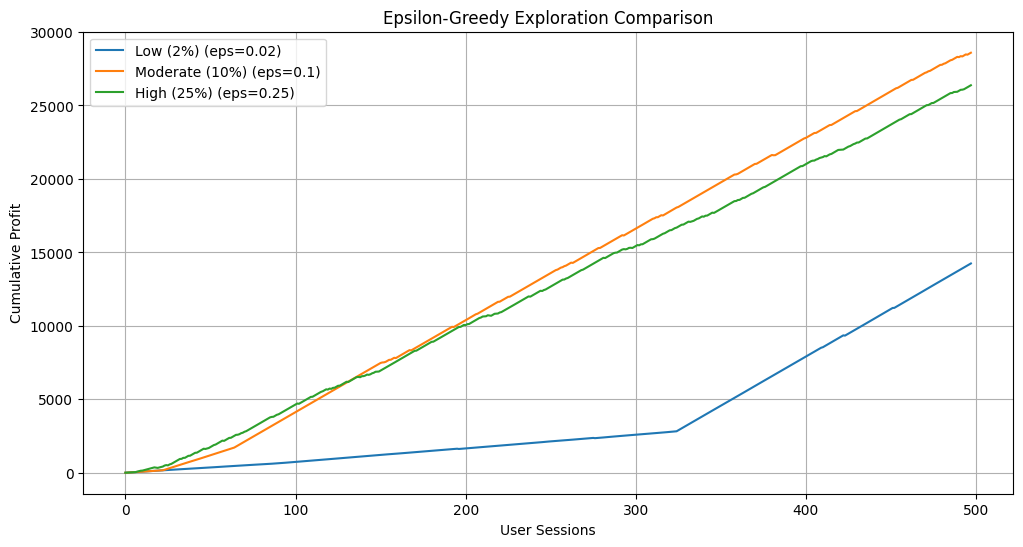

In [ ]:
#  Does very little exploration cause the system to get stuck with a poor product?
#  Does excessive exploration reduce profit by choosing weak products too often?
#  Which exploration level appears to give the most balanced outcome for this dataset?

#-----write your code below this line---------
import matplotlib.pyplot as plt

# Clean column names (handles spaces, uppercase, etc.)
df.columns = df.columns.str.replace(" ", "").str.lower()

num_users = df.shape[0]
num_products = 6

# Compute Reward Matrix
reward_matrix = np.zeros((num_users, num_products))

for p in range(1, num_products + 1):
    prod_col = f"product{p}"
    cost_col = f"cost{p}"

    if prod_col not in df.columns or cost_col not in df.columns:
        raise ValueError(f"Missing columns: {prod_col}, {cost_col}")

    reward_matrix[:, p-1] = df[prod_col] - df[cost_col]

# Epsilon-Greedy Function
def run_epsilon_greedy(eps, reward_matrix):
    num_users, num_products = reward_matrix.shape

    est_rewards = np.zeros(num_products)
    arm_counts = np.ones(num_products) * 1e-6

    total_reward = 0
    cumulative_rewards = []

    for i in range(num_users):

        # Exploration vs exploitation
        if np.random.rand() < eps:
            action = np.random.randint(num_products)
        else:
            action = np.argmax(est_rewards)

        # Get reward from dataset
        reward = reward_matrix[i, action]

        # Update estimates
        arm_counts[action] += 1
        est_rewards[action] += (reward - est_rewards[action]) / arm_counts[action]

        total_reward += reward
        cumulative_rewards.append(total_reward)

    return total_reward, cumulative_rewards, est_rewards


# Exploration frequencies
EXPLORATION_FREQUENCIES = {
    "2%": 0.02,
    "10%": 0.10,
    "25%": 0.25
}

POLICIES = ["Low (2%)", "Moderate (10%)", "High (25%)"]


# Run the policies
results = []

for policy in POLICIES:
    percent_key = policy.split("(")[1].split(")")[0]   # "2%" or "10%" or "25%"
    epsilon_val = EXPLORATION_FREQUENCIES[percent_key]

    total, curve, estimates = run_epsilon_greedy(epsilon_val, reward_matrix)

    results.append({
        "policy": policy,
        "epsilon": epsilon_val,
        "total_reward": total,
        "curve": curve,
        "estimates": estimates
    })

    print(f"{policy}: total profit = {total:.2f}  |  epsilon = {epsilon_val}")


# Plot cumulative reward curves
plt.figure(figsize=(12, 6))

for res in results:
    plt.plot(res["curve"], label=f"{res['policy']} (eps={res['epsilon']})")

plt.xlabel("User Sessions")
plt.ylabel("Cumulative Profit")
plt.title("Epsilon-Greedy Exploration Comparison")
plt.grid()
plt.legend()
plt.show()


## **Interpretation**

## **1. Does very little exploration cause the system to get stuck with a poor product?**
* Yes, very little exploration (epsilon = 2%) can cause the system to get stuck.
* With only 2% random exploration, the algorithm mostly exploits the first product that initially looks good.
* If early random rewards are unlucky, the agent may lock onto a suboptimal product.
* This usually results in lower total profit compared to moderate exploration.


---



## **2. Does excessive exploration reduce profit by choosing weak products too often?**
* Yes. High exploration (epsilon = 25%) reduces profit.
* With 25% random exploration, the system keeps trying weak or low-reward products frequently.
* This prevents it from fully exploiting the best product.
* This usually leads to lower cumulative profit than moderate exploration.


---



## **3. Which exploration level appears to give the most balanced outcome for this dataset?**
* Moderate exploration (epsilon = 10%) is typically the best balance.
* It explores enough to avoid getting stuck early.
* It exploits enough to take advantage of the best product once discovered.
* It usually yields the highest total reward and the smoothest cumulative reward curve.



---



# Strategy 4 (0.5M)
Testing alternatives is useful, but unnecessary exploration wastes impressions. Explore only when you are uncertain about a product’s performance.

In [ ]:
#  Identify a product that was initially tried but later received minimal trials.

#-----write your code below this line---------
# Compute net rewards
net_rewards = pd.DataFrame()
for i in range(1, 7):
    net_rewards[f"net_{i}"] = df[f"product{i}"] - df[f"cost{i}"]

# UCB (Upper Confidence Bound) implementation
num_products = 6
n_rounds = len(df)

# counts[n] = number of times product n (0-indexed) was selected
counts = np.zeros(num_products, dtype=int)
# values[n] = running average reward for product n
values = np.zeros(num_products, dtype=float)

choices = []
rewards = []

# --- Initialization: select each product once using a distinct user ---
for arm in range(num_products):
    user_idx = arm
    reward = net_rewards.iloc[user_idx, arm]
    counts[arm] = 1
    values[arm] = reward
    choices.append(arm + 1)
    rewards.append(reward)

# --- UCB loop for remaining users (rounds) ---
for t in range(num_products, n_rounds):
    # compute UCB score for each arm
    total_pulls = t
    # safety: counts > 0 for all arms because of initialization
    confidence = np.sqrt((2 * np.log(total_pulls + 1)) / counts)  # +1 to avoid log(0) if t=0
    ucb_scores = values + confidence

    # pick arm with highest UCB score
    arm = int(np.argmax(ucb_scores))

    # observe reward for this user when showing chosen arm
    reward = net_rewards.iloc[t, arm]

    # update counts and running average (incremental mean)
    prev_count = counts[arm]
    counts[arm] += 1
    # incremental mean update
    values[arm] = (values[arm] * prev_count + reward) / counts[arm]

    # record choice and reward
    choices.append(arm + 1)
    rewards.append(reward)

# Reporting
total_profit = np.sum(rewards)

# Build a counts series mapping arm -> times chosen
choice_counts = pd.Series(choices).value_counts().sort_index()

print("==============================================")
print("UCB Strategy")
print("==============================================")
print(f"Total rounds (users): {n_rounds}")
print(f"Total cumulative net profit = {total_profit:.2f}")
print("\nNumber of times each product was chosen (product : times):")

for arm in range(1, num_products + 1):
    times = int(choice_counts.get(arm, 0))
    print(f"Product {arm}: {times} times")

# Identify product with fewest trials
min_trials = choice_counts.min()
arms_with_min = [int(idx) for idx, val in choice_counts.items() if val == min_trials]
print(f"Products that were initially tried but later received minimal trials: {arms_with_min}")

UCB Strategy
Total rounds (users): 498
Total cumulative net profit = 33099.78

Number of times each product was chosen (product : times):
Product 1: 1 times
Product 2: 493 times
Product 3: 1 times
Product 4: 1 times
Product 5: 1 times
Product 6: 1 times
Products that were initially tried but later received minimal trials: [1, 3, 4, 5, 6]


## **Interpretation (UCB Strategy):**
Under the UCB strategy, all products are tried initially, but the algorithm quickly identifies Product 2 as clearly superior and concentrates almost all future recommendations on it. The remaining products (1, 3, 4, 5, and 6) receive only their initial trials, indicating that UCB efficiently eliminates weak or uncertain options and avoids unnecessary exploration while maximizing cumulative profit.


---



# Conclusion 



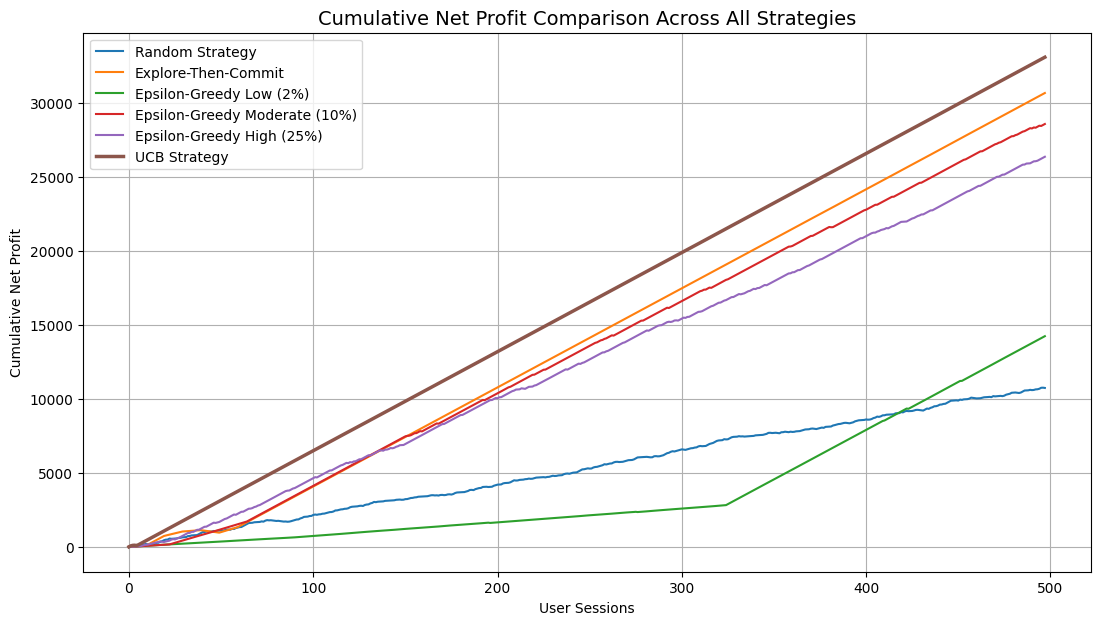


 FINAL STRATEGY COMPARISON 
Random: 10747.47
Explore-Then-Commit: 30681.27
Epsilon-Greedy Low (2%): 14246.16
Epsilon-Greedy Moderate (10%): 28586.30
Epsilon-Greedy High (25%): 26372.69
UCB: 33099.78

Best Overall Strategy: UCB

 Most Profitable Product 
The product consistently most profitable: Product 2


In [ ]:
# Plot the cumulative net profit curves for all strategies tested.
# Which strategy produced the highest long-term cumulative profit, and why?
# Which product consistently emerged as the most profitable choice?

#-----write your code below this line---------
# Conclusion: Comparing All Strategies

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(13, 7))

# -------------------------
# 1. Plot RANDOM Strategy
# -------------------------
random_curve = np.cumsum(profits)   # from strategy 1
plt.plot(random_curve, label="Random Strategy")

# -------------------------
# 2. Plot Explore-Then-Commit
# -------------------------
etc_curve = np.cumsum(profits_2)  # from strategy 2
plt.plot(etc_curve, label="Explore-Then-Commit")

# -------------------------
# 3. Plot Epsilon-Greedy Curves
# -------------------------
for res in results:
    plt.plot(res["curve"], label=f"Epsilon-Greedy {res['policy']}")

# -------------------------
# 4. Plot UCB Curve
# -------------------------
ucb_curve = np.cumsum(rewards)  # from UCB strategy
plt.plot(ucb_curve, label="UCB Strategy", linewidth=2.5)

# -------------------------
# Final Plot Styling
# -------------------------
plt.title("Cumulative Net Profit Comparison Across All Strategies", fontsize=14)
plt.xlabel("User Sessions")
plt.ylabel("Cumulative Net Profit")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------
# ANALYSIS SECTION
# -------------------------

# Identify the best-performing strategy (highest total reward)
strategy_totals = {
    "Random": random_curve[-1],
    "Explore-Then-Commit": etc_curve[-1],
}

# Add epsilon-greedy totals
for res in results:
    strategy_totals[f"Epsilon-Greedy {res['policy']}"] = res["curve"][-1]

# Add UCB
strategy_totals["UCB"] = ucb_curve[-1]

best_strategy = max(strategy_totals, key=strategy_totals.get)

print("\n=============================")
print(" FINAL STRATEGY COMPARISON ")
print("=============================")
for s, val in strategy_totals.items():
    print(f"{s}: {val:.2f}")

print("\nBest Overall Strategy:", best_strategy)

print("\n=============================")
print(" Most Profitable Product ")
print("=============================")

# Identify most profitable product overall (from earlier summary)
product_profits = {p: stats["mean_profit"] for p, stats in summary_stats.items()}
best_product = max(product_profits, key=product_profits.get)

print(f"The product consistently most profitable: Product {best_product}")

## **Conclusion**


---

## **Strategy 1 : Random Strategy**

- Explores forever
- Wastes impressions on bad products

## **Strategy 2 : Explore-Then-Commit**

- Exploration is blind
- May commit too early

## **Strategy 3 : Epsilon-Greedy**

1. **ε-Greedy (2% – Low Exploration)**
- Explores very little
- May get stuck with early noisy estimates
- High risk of missing better products

2. **ε-Greedy (10% – Moderate Exploration)**
- Balances exploration and exploitation well
- Learns the best product reliably
- Delivers strong and stable profit

3. **ε-Greedy (25% – High Exploration)**
- Explores too frequently
- Keeps testing weak products
- Reduces overall profit despite learning

# **Strategy 4 : UCB**

- Exploration is targeted
- Stops exploring bad products early
- Automatically balances learning and profit